# Q2 – Human Parsing and Agnostic Representation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

import torch

print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

Sat Jul 11 13:25:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Environment Setup

In [ ]:
!pip -q install transformers accelerate timm sentencepiece
!pip -q install opencv-python pillow matplotlib tqdm
!pip -q install rembg onnxruntime

## 2. Dataset Preparation

In [ ]:
!mkdir -p /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset

!unzip -q \
"/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip" \
-d "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset"

unzip:  cannot find or open /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip, /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip.zip or /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip.ZIP.


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['XIPL_SDE_Assessment']


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/XIPL_SDE_Assessment"):
    print(root)

/content/drive/MyDrive/XIPL_SDE_Assessment
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/agnostic
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/parsing_maps
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/garment_masks


In [ ]:
import os

DATASET = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset"

for root, dirs, files in os.walk(DATASET):
    print(root)

/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/XIPL_SDE_Assessment"))

['Q2']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/XIPL_SDE_Assessment"))

['V5.zip', 'Q2']


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/XIPL_SDE_Assessment/V5.zip"
extract_to = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Dataset extracted successfully")

✅ Dataset extracted successfully


In [ ]:
!find /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset -maxdepth 3

/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/sample_output_q1.json
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/person_side_pose.jpg
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/no_person.jpg
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/edge_cases_manifest.csv
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/person_crossed_arms.jpg
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/person_seated.jpg
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/SUBMISSION_TEMPLATE.md
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/evaluation_template_q4.csv
/content/drive/MyDrive/XIPL_SDE_Asses

In [ ]:
import os

ROOT = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files"

PERSON_PATH = os.path.join(ROOT, "test_pairs", "person")
GARMENT_PATH = os.path.join(ROOT, "test_pairs", "garment")
EDGE_PATH = os.path.join(ROOT, "edge_cases")

OUTPUT_ROOT = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2"

PARSING_PATH = os.path.join(OUTPUT_ROOT, "parsing_maps")
AGNOSTIC_PATH = os.path.join(OUTPUT_ROOT, "agnostic")
GARMENT_MASK_PATH = os.path.join(OUTPUT_ROOT, "garment_masks")
CLOTHING_MASK_PATH = os.path.join(OUTPUT_ROOT, "clothing_masks")

os.makedirs(PARSING_PATH, exist_ok=True)
os.makedirs(AGNOSTIC_PATH, exist_ok=True)
os.makedirs(GARMENT_MASK_PATH, exist_ok=True)
os.makedirs(CLOTHING_MASK_PATH, exist_ok=True)

print("Persons :", os.listdir(PERSON_PATH))
print("Garments:", os.listdir(GARMENT_PATH))
print("Edges   :", os.listdir(EDGE_PATH))

Persons : ['person_02.png', 'person_04.png', 'person_05.png', 'person_03.png', 'person_01.png']
Garments: ['garment_01.jpg', 'garment_03.jpg', 'garment_02.jpg', 'garment_04.jpg', 'garment_05.jpg']
Edges   : ['person_side_pose.jpg', 'no_person.jpg', 'edge_cases_manifest.csv', 'person_crossed_arms.jpg', 'person_seated.jpg']


## 3. Load SCHP Model

In [ ]:
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(
    "pirocheto/schp-atr-18",
    trust_remote_code=True
)

model = AutoModelForSemanticSegmentation.from_pretrained(
    "pirocheto/schp-atr-18",
    trust_remote_code=True
)

model.to(DEVICE)
model.eval()

print("✅ SCHP Loaded Successfully")
print("Device:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/302 [00:00<?, ?B/s]

image_processing_schp.py:   0%|          | 0.00/3.37k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/pirocheto/schp-atr-18:
- image_processing_schp.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

configuration_schp.py:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

...

modeling_schp.py:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/pirocheto/schp-atr-18:
- modeling_schp.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/267M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/722 [00:00<?, ?it/s]

✅ SCHP Loaded Successfully
Device: cuda


## 4. Generate Parsing Maps

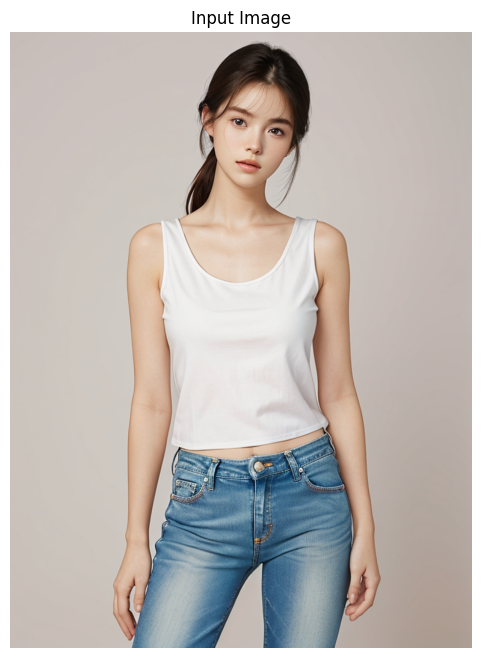

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = os.path.join(PERSON_PATH, "person_01.png")

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,8))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [ ]:
inputs = processor(
    images=image,
    return_tensors="pt"
).to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

print(type(outputs))

<class 'transformers_modules.pirocheto.schp_hyphen_atr_hyphen_18.61f4ff3c508b899904e495cefbbaff9cacadeb45.modeling_schp.SCHPSemanticSegmenterOutput'>


In [ ]:
import numpy as np

parsing_map = outputs.parsing_logits.argmax(dim=1)[0].cpu().numpy()

print("Shape:", parsing_map.shape)
print("Classes:", np.unique(parsing_map))

Shape: (512, 512)
Classes: [ 0  2  4  6  8 11 14 15]


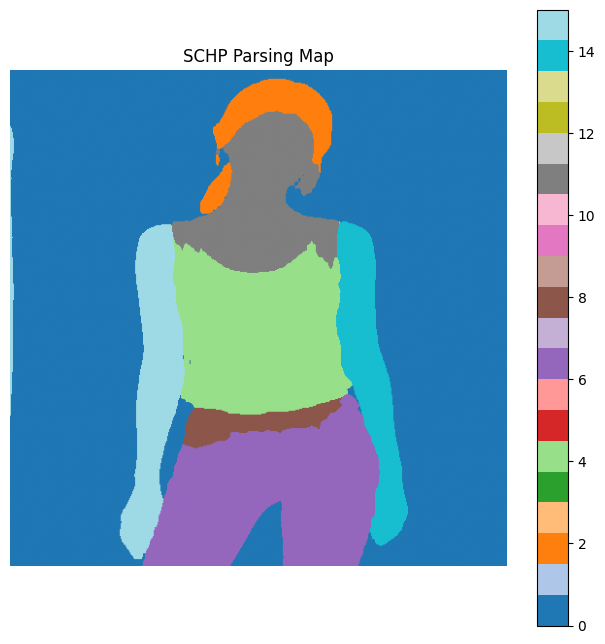

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(parsing_map, cmap="tab20")
plt.colorbar()
plt.title("SCHP Parsing Map")
plt.axis("off")
plt.show()

In [ ]:
import cv2

cv2.imwrite(
    os.path.join(PARSING_PATH, "person_01.png"),
    parsing_map.astype(np.uint8)
)

print("✅ Parsing map saved.")

✅ Parsing map saved.


In [ ]:
import torch
import numpy as np

# Get class probabilities
prob = torch.softmax(outputs.parsing_logits[0], dim=0).cpu().numpy()

upper_prob = prob[4]     # Upper clothes
dress_prob = prob[7]     # Dress
belt_prob = prob[8]      # Belt

cloth_mask = (
    (upper_prob > 0.20) |
    (dress_prob > 0.20) |
    (belt_prob > 0.20)
).astype(np.uint8)

print("Mask created.")

Mask created.


In [ ]:
import cv2

h, w = cloth_mask.shape

# Only refine the upper torso region
shoulder_region = np.zeros_like(cloth_mask)

shoulder_region[
    int(h*0.08):int(h*0.40),
    :
] = 1

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5,5)
)

expanded = cv2.dilate(
    cloth_mask,
    kernel,
    iterations=1
)

cloth_mask = np.where(
    shoulder_region == 1,
    expanded,
    cloth_mask
)

In [ ]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3,3)
)

cloth_mask = cv2.morphologyEx(
    cloth_mask,
    cv2.MORPH_CLOSE,
    kernel
)

In [ ]:
cloth_mask = cv2.resize(
    cloth_mask,
    (image.width, image.height),
    interpolation=cv2.INTER_NEAREST
)

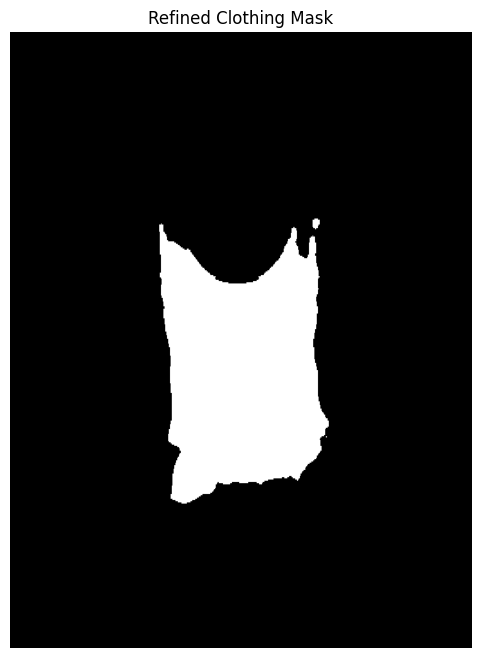

In [ ]:
plt.figure(figsize=(6,8))

plt.imshow(
    cloth_mask,
    cmap="gray"
)

plt.title("Refined Clothing Mask")
plt.axis("off")
plt.show()

## 5. Create Agnostic Images

In [ ]:
import numpy as np

# Convert PIL image to NumPy array
image_np = np.array(image)

# Copy original image
agnostic = image_np.copy()

# Replace clothing pixels with gray
agnostic[cloth_mask == 1] = [128, 128, 128]

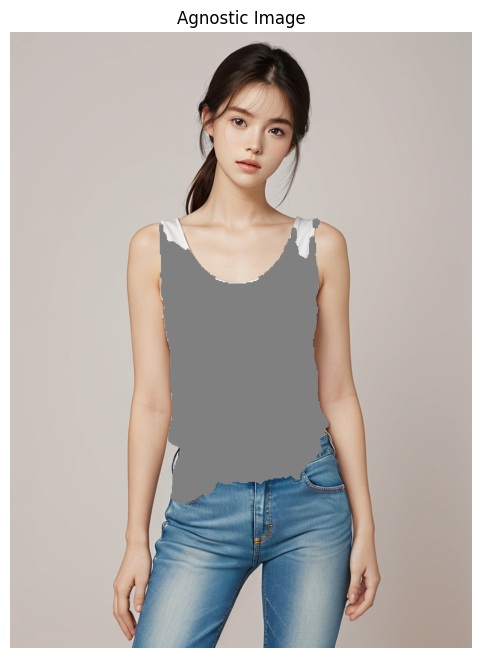

In [ ]:
plt.figure(figsize=(6,8))
plt.imshow(agnostic)
plt.title("Agnostic Image")
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
import os

save_path = os.path.join(
    AGNOSTIC_PATH,
    "person_01.png"
)

Image.fromarray(agnostic).save(save_path)

print("✅ Agnostic image saved to:", save_path)

✅ Agnostic image saved to: /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/agnostic/person_01.png


In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

person_files = sorted([
    f for f in os.listdir(PERSON_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Found", len(person_files), "person images")

Found 5 person images


In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

for file_name in tqdm(person_files):

    image_path = os.path.join(PERSON_PATH, file_name)

    image = Image.open(image_path).convert("RGB")

    # ---------------------------
    # SCHP Inference
    # ---------------------------
    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    # ---------------------------
    # Parsing Map
    # ---------------------------
    parsing_map = outputs.parsing_logits.argmax(dim=1)[0].cpu().numpy()

    cv2.imwrite(
        os.path.join(PARSING_PATH, file_name),
        parsing_map.astype(np.uint8)
    )

    # ---------------------------
    # Confidence Mask
    # ---------------------------
    prob = torch.softmax(
        outputs.parsing_logits[0],
        dim=0
    ).cpu().numpy()

    upper = prob[4]
    dress = prob[7]
    belt = prob[8]

    cloth_mask = (
        (upper > 0.20) |
        (dress > 0.20) |
        (belt > 0.20)
    ).astype(np.uint8)

    # ---------------------------
    # Morphology
    # ---------------------------
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5,5)
    )

    cloth_mask = cv2.morphologyEx(
        cloth_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    cloth_mask = cv2.resize(
        cloth_mask,
        (image.width, image.height),
        interpolation=cv2.INTER_NEAREST
    )

    # ---------------------------
    # Save Binary Clothing Mask
    # ---------------------------
    Image.fromarray(
        (cloth_mask * 255).astype(np.uint8)
    ).save(
        os.path.join(
            CLOTHING_MASK_PATH,
            file_name
        )
    )

    # ---------------------------
    # Agnostic Image
    # ---------------------------
    image_np = np.array(image)

    agnostic = image_np.copy()

    agnostic[cloth_mask == 1] = [128, 128, 128]

    Image.fromarray(
        agnostic
    ).save(
        os.path.join(
            AGNOSTIC_PATH,
            file_name
        )
    )

print("✅ Batch processing completed.")

100%|██████████| 5/5 [00:04<00:00,  1.10it/s]

✅ Batch processing completed.


In [ ]:
import os

print(os.listdir(CLOTHING_MASK_PATH))

['person_02.png', 'person_04.png', 'person_05.png', 'person_03.png', 'person_01.png']


L


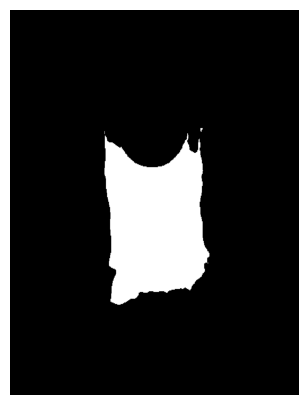

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

mask = Image.open(
    "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks/person_01.png"
)

print(mask.mode)

plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
print("Parsing Maps:")
print(sorted(os.listdir(PARSING_PATH)))

print("\nAgnostic Images:")
print(sorted(os.listdir(AGNOSTIC_PATH)))

Parsing Maps:
['person_01.png', 'person_02.png', 'person_03.png', 'person_04.png', 'person_05.png']

Agnostic Images:
['person_01.png', 'person_02.png', 'person_03.png', 'person_04.png', 'person_05.png']


## 6. Handle Edge Cases

In [ ]:
import os

edge_files = sorted([
    f for f in os.listdir(EDGE_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print(edge_files)

['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']


In [ ]:
import os

edge_files = sorted([
    f for f in os.listdir(EDGE_PATH)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Edge Files:")
print(edge_files)

Edge Files:
['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']


In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

EDGE_OUTPUT = os.path.join(OUTPUT_ROOT, "edge_cases")

EDGE_PARSING = os.path.join(EDGE_OUTPUT, "parsing_maps")
EDGE_AGNOSTIC = os.path.join(EDGE_OUTPUT, "agnostic")

os.makedirs(EDGE_PARSING, exist_ok=True)
os.makedirs(EDGE_AGNOSTIC, exist_ok=True)

for file_name in tqdm(edge_files):

    # Skip non-image files
    if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image_path = os.path.join(EDGE_PATH, file_name)

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    parsing_map = outputs.parsing_logits.argmax(dim=1)[0].cpu().numpy()

    unique_classes = np.unique(parsing_map)

    # If only background is predicted, treat it as "no person"
    if len(unique_classes) <= 1:
        print(f"Skipping {file_name} (No person detected)")
        continue

    # Save parsing map
    cv2.imwrite(
        os.path.join(EDGE_PARSING, file_name),
        parsing_map.astype(np.uint8)
    )

    # -----------------------
    # Clothing Mask
    # -----------------------

    prob = torch.softmax(outputs.parsing_logits[0], dim=0).cpu().numpy()

    cloth_mask = (
        (prob[4] > 0.20) |
        (prob[7] > 0.20) |
        (prob[8] > 0.20)
    ).astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5,5)
    )

    cloth_mask = cv2.morphologyEx(
        cloth_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    cloth_mask = cv2.resize(
        cloth_mask,
        (image.width, image.height),
        interpolation=cv2.INTER_NEAREST
    )

    image_np = np.array(image)

    agnostic = image_np.copy()

    agnostic[cloth_mask == 1] = [128,128,128]

    Image.fromarray(agnostic).save(
        os.path.join(
            EDGE_AGNOSTIC,
            file_name
        )
    )

    print(f"Processed {file_name}")

print("\n✅ Edge case processing completed.")

 25%|██▌       | 1/4 [00:00<00:00,  7.30it/s]

Processed no_person.jpg


 50%|█████     | 2/4 [00:00<00:00,  7.26it/s]

Processed person_crossed_arms.jpg


 75%|███████▌  | 3/4 [00:00<00:00,  6.46it/s]

Processed person_seated.jpg


100%|██████████| 4/4 [00:00<00:00,  6.38it/s]

Processed person_side_pose.jpg

✅ Edge case processing completed.


In [ ]:
print("Parsing Maps:")
print(sorted(os.listdir(EDGE_PARSING)))

print("\nAgnostic Images:")
print(sorted(os.listdir(EDGE_AGNOSTIC)))

Parsing Maps:
['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']

Agnostic Images:
['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']


## 7. Garment Segmentation using rembg

In [ ]:
!pip -q install rembg onnxruntime

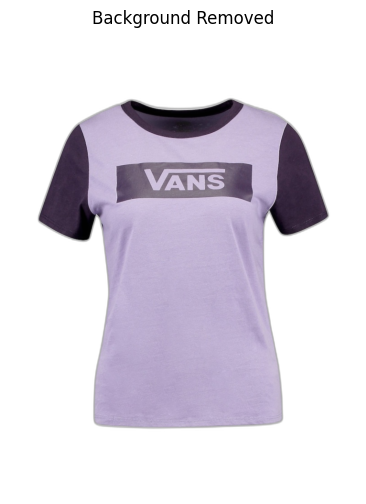

In [ ]:
from rembg import remove
from PIL import Image
import matplotlib.pyplot as plt
import os

garment_path = os.path.join(
    GARMENT_PATH,
    "garment_01.jpg"
)

garment = Image.open(garment_path).convert("RGBA")

result = remove(garment)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.axis("off")
plt.title("Background Removed")
plt.show()

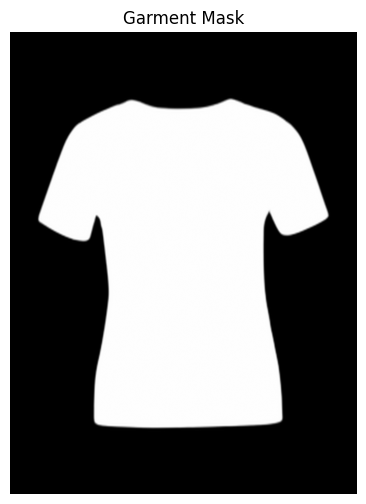

In [ ]:
import numpy as np

rgba = np.array(result)

mask = rgba[:,:,3]

plt.figure(figsize=(6,6))
plt.imshow(mask,cmap="gray")
plt.axis("off")
plt.title("Garment Mask")
plt.show()

In [ ]:
import cv2

save_path = os.path.join(
    GARMENT_MASK_PATH,
    "garment_01.png"
)

cv2.imwrite(save_path,mask)

print("Saved:",save_path)

Saved: /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/garment_masks/garment_01.png


## 8. Verify Outputs

In [ ]:
from rembg import remove
from PIL import Image
import numpy as np
import cv2
import os
from tqdm import tqdm

garment_files = sorted([
    f for f in os.listdir(GARMENT_PATH)
    if f.lower().endswith((".jpg",".jpeg",".png"))
])

print(garment_files)

for file in tqdm(garment_files):

    img = Image.open(
        os.path.join(GARMENT_PATH,file)
    ).convert("RGBA")

    result = remove(img)

    rgba = np.array(result)

    mask = rgba[:,:,3]

    out_name = os.path.splitext(file)[0]+".png"

    cv2.imwrite(
        os.path.join(
            GARMENT_MASK_PATH,
            out_name
        ),
        mask
    )

print("\n✅ All garment masks generated.")

['garment_01.jpg', 'garment_02.jpg', 'garment_03.jpg', 'garment_04.jpg', 'garment_05.jpg']


100%|██████████| 5/5 [00:20<00:00,  4.15s/it]


✅ All garment masks generated.


In [ ]:
print("Parsing Maps :",len(os.listdir(PARSING_PATH)))
print("Agnostic Images :",len(os.listdir(AGNOSTIC_PATH)))
print("Garment Masks :",len(os.listdir(GARMENT_MASK_PATH)))

print("\nGarment Masks")

print(sorted(os.listdir(GARMENT_MASK_PATH)))

Parsing Maps : 5
Agnostic Images : 5
Garment Masks : 5

Garment Masks
['garment_01.png', 'garment_02.png', 'garment_03.png', 'garment_04.png', 'garment_05.png']


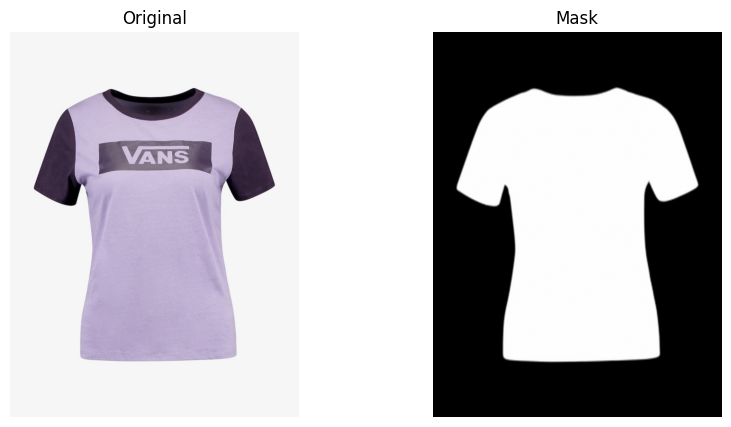

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(
    Image.open(
        os.path.join(GARMENT_PATH,"garment_01.jpg")
    )
)

ax[0].set_title("Original")

ax[0].axis("off")

ax[1].imshow(
    Image.open(
        os.path.join(GARMENT_MASK_PATH,"garment_01.png")
    ),
    cmap="gray"
)

ax[1].set_title("Mask")

ax[1].axis("off")

plt.show()

In [ ]:
readme = """# Q2 - Human Parsing and Agnostic Representation

## Objective

Generate an agnostic person representation and garment masks as preprocessing steps for an AI-based virtual try-on pipeline.

## Models Used

### Human Parsing
- SCHP (pirocheto/schp-atr-18)

### Garment Segmentation
- rembg

## Model Selection and Comparison

| Model | Advantages | Limitations | Decision |
|--------|------------|-------------|----------|
| **SCHP (Selected)** | Specifically designed for human parsing, predicts body-part labels (upper clothes, arms, face, pants), lightweight (~267 MB), easy to run on Colab | Thin shoulder straps may occasionally be classified as arm regions | ✅ Selected |
| **SAM + Grounding DINO** | High-quality segmentation, flexible object detection | Requires multiple large models, slower inference, more complex pipeline | Not selected |
| **DensePose** | Accurate body surface and pose estimation | Does not directly provide clothing segmentation | Not selected |

## Pipeline

1. Load person image.
2. Run SCHP human parsing.
3. Generate parsing map.
4. Create clothing mask.
5. Generate agnostic image.
6. Process edge cases.
7. Generate garment masks using rembg.

## Edge Case Handling

- Crossed arms
- Side pose
- Seated person
- Sleeveless garments (confidence-based refinement)
- No-person image

## Outputs

- parsing_maps/
- agnostic/
- garment_masks/
- edge_cases/

## Libraries

- PyTorch
- Transformers
- OpenCV
- NumPy
- Pillow
- rembg
- ONNX Runtime

## Author

Nandana R
"""

with open("/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/README.md", "w") as f:
    f.write(readme)

print("✅ README.md created successfully.")

✅ README.md created successfully.


In [ ]:
import os

MASK_OUTPUT_DIR = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks"

os.makedirs(MASK_OUTPUT_DIR, exist_ok=True)

print("✅ Folder created:", MASK_OUTPUT_DIR)

✅ Folder created: /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks
